# 01 · Exploración de datos (EDA)

Objetivo: entender los datos y escoger el flujo con la matriz de decisión (roadmap, sección 6).

## Sección 0 · Setup

In [1]:
import sys
from pathlib import Path

# El notebook vive en analysis/; agregamos la raíz del repo para poder importar data_pipeline
ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data_pipeline.connection import get_connection, list_files, BASE

SEED = 42
FECHA_CORTE = "2026-06-17"  # fin del dataset = "hoy" simulado
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

con = get_connection()

def q(sql):
    """Corre SQL y devuelve un DataFrame."""
    return con.sql(sql).df()

def columnas(tabla):
    return list(q(f"DESCRIBE SELECT * FROM {tabla}")["column_name"])

In [ ]:
files = con.sql(f"SELECT file FROM glob('{BASE}/complaints/**/*.csv') ORDER BY file LIMIT 60").df()['file'].tolist()
tr = f"read_csv_auto({files}, hive_partitioning=true, union_by_name=true)"

files = con.sql(f"SELECT file FROM glob('{BASE}/call_transcripts/**/*.csv') ORDER BY file LIMIT 60").df()['file'].tolist()
tr = f"read_csv_auto({files}, hive_partitioning=true, union_by_name=true)"

print(con.sql(f"SELECT count(*) filas, count(DISTINCT customer_text) textos_cliente_distintos FROM {tr}").df())
print(con.sql(f"SELECT detected_language, count(*) n FROM {tr} GROUP BY 1 ORDER BY n DESC").df())
print(con.sql(f"SELECT detected_intents, count(*) n FROM {tr} GROUP BY 1 ORDER BY n DESC LIMIT 10").df())
print(con.sql(f"SELECT customer_text, count(*) n FROM {tr} GROUP BY 1 ORDER BY n DESC LIMIT 15").df().to_string())

cp = f"read_csv_auto({files}, hive_partitioning=true, union_by_name=true)"
print(con.sql(f"SELECT subcategory, description, count(*) n FROM {cp} GROUP BY 1,2 ORDER BY n DESC LIMIT 15").df().to_string())


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

            subcategory                         description    n
0   Cargo no reconocido  Queja relacionada con transactions  702
1        Cobro indebido          Queja relacionada con fees  674
2  Atención en sucursal        Queja relacionada con branch  654
3   Calidad de servicio       Queja relacionada con service  632
4      Problema con app     Queja relacionada con technical  626
5                   NaN        Queja relacionada con branch   83
6                   NaN          Queja relacionada con fees   83
7                   NaN       Queja relacionada con service   76
8                   NaN  Queja relacionada con transactions   70
9                   NaN     Queja relacionada con technical   56


### Inventario de archivos

In [14]:
files = list_files(con)
files["table"] = files["file"].str.replace(BASE + "/", "").str.split("/").str[0].str.replace(".csv", "")
files["ext"] = files["file"].str.extract(r"\.(\w+)$")
files.groupby(["table", "ext"]).size().rename("archivos").to_frame()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,,archivos
table,ext,
branches,csv,1
call_center_interactions,csv,1097
call_transcripts,csv,1097
campaign_sends,csv,1083
complaints,csv,1097
customers,csv,1
daily_exchange_rates,csv,1
digital_events,csv,1097
marketing_campaigns,csv,1


### Vistas (una por tabla)

Todo es CSV. Las tablas grandes están particionadas por día (`year=/month=/day=`, un archivo por día).

In [15]:
SMALL = ["customers", "products", "branches", "service_agents", "daily_exchange_rates"]
BIG = ["transactions", "call_center_interactions", "call_transcripts", "complaints", "satisfaction_surveys"]

for t in SMALL:
    con.execute(f"CREATE OR REPLACE VIEW {t} AS SELECT * FROM read_csv('{BASE}/{t}.csv', header=true)")

for t in BIG:
    con.execute(f"""
        CREATE OR REPLACE VIEW {t}_remote AS
        SELECT * FROM read_csv('{BASE}/{t}/**/*.csv', header=true, hive_partitioning=true, filename=true)
    """)

con.sql("SELECT COUNT(*) AS n FROM customers").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n
0,150000


In [16]:
DATA = ROOT / "data"
DATA.mkdir(exist_ok=True)

for t in ["complaints", "satisfaction_surveys", "call_center_interactions", "call_transcripts"]:
    out = DATA / f"{t}.parquet"
    if not out.exists():
        print("Descargando", t, "...")
        con.execute(f"COPY (SELECT * FROM {t}_remote) TO '{out}' (FORMAT parquet)")
    con.execute(f"CREATE OR REPLACE VIEW {t} AS SELECT * FROM read_parquet('{out}')")

# transactions: solo los últimos 12 meses (jul-2025 a jun-2026)
out = DATA / "transactions_12m.parquet"
if not out.exists():
    print("Descargando transactions (12 meses) ...")
    # Se listan solo las carpetas de esos meses para no tocar los demás archivos en S3
    rutas = [f"{BASE}/transactions/year=2025/month={m:02d}/*/*.csv" for m in range(7, 13)]
    rutas += [f"{BASE}/transactions/year=2026/*/*/*.csv"]
    con.execute(f"""
        COPY (SELECT * FROM read_csv({rutas}, header=true, hive_partitioning=true, filename=true))
        TO '{out}' (FORMAT parquet)
    """)
con.execute(f"CREATE OR REPLACE VIEW transactions AS SELECT * FROM read_parquet('{out}')")

# Las tablas chicas también se guardan localmente para no depender de internet
for t in SMALL:
    out = DATA / f"{t}.parquet"
    if not out.exists():
        con.execute(f"COPY (SELECT * FROM {t}) TO '{out}' (FORMAT parquet)")
    con.execute(f"CREATE OR REPLACE VIEW {t} AS SELECT * FROM read_parquet('{out}')")

TABLAS = SMALL + BIG
print("Listo:", TABLAS)

Listo: ['customers', 'products', 'branches', 'service_agents', 'daily_exchange_rates', 'transactions', 'call_center_interactions', 'call_transcripts', 'complaints', 'satisfaction_surveys']


In [17]:
# Prueba rápida con una tabla chica
con.sql("SELECT COUNT(*) AS n FROM customers").df()

,n
0,150000


## Sección 1 · Inventario y esquema

In [18]:
# filas en tabla vs el diccionario
# Llenar con las filas que dice el diccionario (p. ej. "transactions": 5_000_000)
FILAS_DICCIONARIO = {
    "customers": None, "products": None, "branches": None, "service_agents": None,
    "daily_exchange_rates": None, "transactions": None, "call_center_interactions": None,
    "call_transcripts": None, "complaints": None, "satisfaction_surveys": None,
}

conteos = pd.DataFrame(
    [(t, q(f"SELECT COUNT(*) AS n FROM {t}")["n"][0]) for t in TABLAS],
    columns=["tabla", "filas"],
)
conteos["diccionario"] = conteos["tabla"].map(FILAS_DICCIONARIO)
conteos["nota"] = np.where(conteos["tabla"] == "transactions", "solo últimos 12 meses", "")
conteos

,tabla,filas,diccionario,nota
0,customers,150000,None,
1,products,400000,None,
2,branches,350,None,
3,service_agents,1200,None,
4,daily_exchange_rates,13164,None,
5,transactions,1429456,None,solo últimos 12 meses
6,call_center_interactions,686296,None,
7,call_transcripts,171321,None,
8,complaints,67095,None,
9,satisfaction_surveys,212759,None,


In [19]:
# rango de fechas por partición

rangos = []
for t in BIG:
    r = q(f"""
        SELECT MIN(make_date(year::INT, month::INT, day::INT)) AS desde,
               MAX(make_date(year::INT, month::INT, day::INT)) AS hasta,
               COUNT(DISTINCT make_date(year::INT, month::INT, day::INT)) AS dias_con_datos
        FROM {t}
    """)
    rangos.append({"tabla": t, **r.iloc[0].to_dict()})
pd.DataFrame(rangos)

,tabla,desde,hasta,dias_con_datos
0,transactions,2025-07-01,2026-06-17,352
1,call_center_interactions,2023-06-17,2026-06-17,1097
2,call_transcripts,2023-06-17,2026-06-17,1097
3,complaints,2023-06-17,2026-06-17,1097
4,satisfaction_surveys,2023-06-17,2026-06-17,1097


In [20]:
# columnas y tipos en cada tabla
for t in TABLAS:
    d = q(f"DESCRIBE {t}")
    print(f"\n## {t} ({len(d)} columnas)")
    print(", ".join(f"{c} ({ty})" for c, ty in zip(d["column_name"], d["column_type"])))


## customers (27 columnas)
customer_id (VARCHAR), document_number (VARCHAR), document_type (VARCHAR), first_name (VARCHAR), last_name (VARCHAR), date_of_birth (DATE), gender (VARCHAR), email (VARCHAR), mobile_phone (VARCHAR), landline_phone (VARCHAR), address (VARCHAR), city (VARCHAR), state (VARCHAR), country (VARCHAR), postal_code (VARCHAR), detected_accent (VARCHAR), segment (VARCHAR), credit_score (DOUBLE), estimated_monthly_income (DOUBLE), occupation (VARCHAR), marital_status (VARCHAR), education_level (VARCHAR), registration_date (TIMESTAMP), registration_branch_id (VARCHAR), customer_status (VARCHAR), last_updated (TIMESTAMP), accepts_marketing (BOOLEAN)

## products (17 columnas)
product_id (VARCHAR), customer_id (VARCHAR), product_type (VARCHAR), product_number (VARCHAR), currency (VARCHAR), current_balance (DOUBLE), credit_limit (DOUBLE), interest_rate (DOUBLE), opening_date (DATE), expiration_date (DATE), opening_branch_id (VARCHAR), product_status (VARCHAR), opening_chann

In [22]:
# cambió el esquema con el tiempo?
evolucion = []
for t in BIG:
    arch = files.loc[files["file"].str.startswith(f"{BASE}/{t}/"), "file"].sort_values().tolist()
    muestra = [arch[0], arch[len(arch) // 2], arch[-1]]
    esquemas = {f.split("/")[-1]: columnas(f"read_csv('{f}', header=true)") for f in muestra}
    base = set(next(iter(esquemas.values())))
    for nombre, cols in esquemas.items():
        evolucion.append({
            "tabla": t, "archivo": nombre, "n_columnas": len(cols),
            "nuevas": sorted(set(cols) - base), "faltantes": sorted(base - set(cols)),
        })
pd.DataFrame(evolucion)

,tabla,archivo,n_columnas,nuevas,faltantes
0,transactions,transactions_20230617.csv,25,[],[]
1,transactions,transactions_20241216.csv,25,[],[]
2,transactions,transactions_20260617.csv,25,[],[]
3,call_center_interactions,call_center_interactions_20230617.csv,24,[],[]
4,call_center_interactions,call_center_interactions_20241216.csv,24,[],[]
5,call_center_interactions,call_center_interactions_20260617.csv,24,[],[]
6,call_transcripts,call_transcripts_20230617.csv,21,[],[]
7,call_transcripts,call_transcripts_20241216.csv,21,[],[]
8,call_transcripts,call_transcripts_20260617.csv,21,[],[]
9,complaints,complaints_20230617.csv,30,[],[]


### Hallazgos · Sección 1
- **10 tablas cargadas**; las grandes cubren **17-jun-2023 a 17-jun-2026 (1097 días, sin huecos)**. `transactions` se cargó solo para los últimos 12 meses: **1,43 M filas en 352 días**.
- Tamaños: 150k clientes, 400k productos, **686k interacciones**, 171k transcripts (**25 %** de las interacciones), 213k encuestas (31 %), **67k quejas**.
- **El esquema no cambió en el tiempo**: el primer, el intermedio y el último archivo de cada tabla tienen las mismas columnas.
- Pendiente: llenar `FILAS_DICCIONARIO` con los conteos del diccionario para cerrar la comparación. `digital_events`, `campaign_sends` y `marketing_campaigns` existen en S3 pero no se cargaron (no aportan a ninguna opción).

## Sección 2 · Calidad de datos

In [23]:
# nulos por columna
resumen = {t: q(f"SUMMARIZE {t}") for t in TABLAS}

nulos = pd.concat(
    [r.assign(tabla=t)[["tabla", "column_name", "column_type", "null_percentage", "approx_unique"]]
     for t, r in resumen.items()]
)
nulos["null_percentage"] = pd.to_numeric(nulos["null_percentage"].astype(str).str.rstrip("%"), errors="coerce")
nulos[nulos["null_percentage"] > 0].sort_values("null_percentage", ascending=False)

,tabla,column_name,column_type,null_percentage,approx_unique
10,complaints,origin_interaction_id,VARCHAR,100.00,0
20,complaints,closing_date,TIMESTAMP,96.30,2006
25,complaints,resolution_satisfaction,DOUBLE,96.30,5
24,complaints,compensation_granted,DOUBLE,93.08,3311
15,satisfaction_surveys,question_3_response,DOUBLE,81.15,5
...,...,...,...,...,...
17,transactions,response_code,VARCHAR,5.00,5
13,call_transcripts,detected_intents,VARCHAR,4.94,1
10,customers,address,VARCHAR,4.91,168966
8,customers,mobile_phone,VARCHAR,3.14,154153


In [ ]:
# duplicados
PK = {  # AJUSTAR según el chunk 1.3
    "customers": "customer_id",
    "products": "product_id",
    "branches": "branch_id",
    "service_agents": "agent_id",
    "transactions": "transaction_id",
    "call_center_interactions": "interaction_id",
    "call_transcripts": "transcript_id",
    "complaints": "complaint_id",
    "satisfaction_surveys": "survey_id",
}
TECNICAS = ["filename", "year", "month", "day"]  # columnas que agregamos al leer, no son datos

filas = []
for t, pk in PK.items():
    cols = [c for c in columnas(t) if c not in TECNICAS]
    try:
        r = q(f"""
            SELECT COUNT(*) AS filas,
                   COUNT(DISTINCT {pk}) AS ids_unicos,
                   COUNT(*) - COUNT(DISTINCT {pk}) AS dup_por_llave,
                   COUNT(*) - (SELECT COUNT(*) FROM (SELECT DISTINCT {", ".join(cols)} FROM {t})) AS dup_exactos
            FROM {t}
        """).iloc[0].to_dict()
        filas.append({"tabla": t, "pk": pk, **r})
    except Exception as e:
        filas.append({"tabla": t, "pk": pk, "error": str(e)[:80]})
dups = pd.DataFrame(filas)
dups["pct_dup_llave"] = (100 * dups["dup_por_llave"] / dups["filas"]).round(2)
dups

In [25]:
t, pk = "complaints", PK["complaints"]
q(f"""
    SELECT * FROM {t}
    WHERE {pk} IN (SELECT {pk} FROM {t} GROUP BY 1 HAVING COUNT(*) > 1 LIMIT 3)
    ORDER BY {pk}
""")

,complaint_id,creation_date,process_date,customer_id,case_type,category,subcategory,reception_channel,affected_product_id,related_branch_id,origin_interaction_id,description,claimed_amount,currency,priority,status,assigned_agent_id,assignment_date,first_response_date,resolution_date,closing_date,sla_breached,resolution_days,resolution,compensation_granted,resolution_satisfaction,is_repeat_complainer,filename,day,month,year


In [ ]:
# huérfanos
FK = [  # (tabla hija, columna, tabla padre, columna padre) · AJUSTAR según 1.3
    ("products", "customer_id", "customers", "customer_id"),
    ("transactions", "customer_id", "customers", "customer_id"),
    ("transactions", "product_id", "products", "product_id"),
    ("call_center_interactions", "customer_id", "customers", "customer_id"),
    ("call_center_interactions", "agent_id", "service_agents", "agent_id"),
    ("call_transcripts", "interaction_id", "call_center_interactions", "interaction_id"),
    ("complaints", "customer_id", "customers", "customer_id"),
    ("complaints", "affected_product_id", "products", "product_id"),
    ("complaints", "origin_interaction_id", "call_center_interactions", "interaction_id"),
    ("satisfaction_surveys", "interaction_id", "call_center_interactions", "interaction_id"),
]

filas = []
for hija, col, padre, pcol in FK:
    try:
        r = q(f"""
            SELECT COUNT(*) AS con_llave,
                   SUM(CASE WHEN p.{pcol} IS NULL THEN 1 ELSE 0 END) AS huerfanos
            FROM {hija} h
            LEFT JOIN (SELECT DISTINCT {pcol} FROM {padre}) p ON h.{col} = p.{pcol}
            WHERE h.{col} IS NOT NULL
        """).iloc[0].to_dict()
        filas.append({"relacion": f"{hija}.{col} → {padre}", **r})
    except Exception as e:
        filas.append({"relacion": f"{hija}.{col} → {padre}", "error": str(e)[:80]})
huerf = pd.DataFrame(filas)
huerf["pct_huerfanos"] = (100 * huerf["huerfanos"] / huerf["con_llave"]).round(2)
huerf

In [ ]:
# llegadas tardías
FECHA_EVENTO = {  # AJUSTAR según 1.3
    "transactions": "transaction_date",
    "call_center_interactions": "interaction_date",
    "complaints": "creation_date",
    "satisfaction_surveys": "survey_date",
}

atrasos = []
for t, col in FECHA_EVENTO.items():
    try:
        r = q(f"""
            SELECT DATE_DIFF('day', CAST({col} AS DATE), make_date(year::INT, month::INT, day::INT)) AS atraso_dias,
                   COUNT(*) AS n
            FROM {t}
            GROUP BY 1
        """)
        r["tabla"] = t
        atrasos.append(r)
    except Exception as e:
        print(t, "→", str(e)[:80])
atrasos = pd.concat(atrasos)
atrasos["pct"] = (100 * atrasos["n"] / atrasos.groupby("tabla")["n"].transform("sum")).round(2)
atrasos.pivot_table(index="atraso_dias", columns="tabla", values="pct").fillna(0).sort_index()

In [28]:
# valores fuera de dominio
for t, r in resumen.items():
    cat = r[(r["column_type"] == "VARCHAR") & (r["approx_unique"] <= 30)]["column_name"]
    for c in cat:
        if c in TECNICAS:
            continue
        vc = q(f"SELECT {c} AS valor, COUNT(*) AS n FROM {t} GROUP BY 1 ORDER BY 2 DESC")
        print(f"\n{t}.{c}: " + " | ".join(f"{v} ({n})" for v, n in zip(vc["valor"], vc["n"])))


customers.document_type: DNI (104749) | CE (15150) | Pasaporte (15062) | CC (15039)

customers.gender: F (50508) | O (49808) | M (49684)

customers.city: Guadalajara (12643) | Ciudad de México (12506) | Querétaro (12500) | Tijuana (12489) | Puebla (12400) | Monterrey (12369) | Bogotá (9140) | Medellín (9107) | Barranquilla (9076) | Cali (8972) | Cartagena (8956) | Rosario (6081) | Buenos Aires (6037) | La Plata (5973) | Mendoza (5959) | Córdoba (5792)

customers.state: Jalisco (12643) | Ciudad de México (12506) | Querétaro (12500) | Baja California (12489) | Puebla (12400) | Nuevo León (12369) | Cundinamarca (9140) | Antioquia (9107) | Atlántico (9076) | Valle del Cauca (8972) | Bolívar (8956) | Santa Fe (6081) | Ciudad Autónoma de Buenos Aires (6037) | Buenos Aires (5973) | Mendoza (5959) | Córdoba (5792)

customers.country: México (74907) | Colombia (45251) | Argentina (29842)

customers.detected_accent: mexican (52505) | nan (44817) | colombian (31666) | argentine (21012)

customer

In [29]:
checks = {  # AJUSTAR nombres según 1.3
    "credit_score fuera de 300–850":
        "SELECT COUNT(*) FROM customers WHERE credit_score NOT BETWEEN 300 AND 850",
    "montos negativos en transactions":
        "SELECT COUNT(*) FROM transactions WHERE amount_usd < 0",
    "transacciones con fecha futura":
        f"SELECT COUNT(*) FROM transactions WHERE CAST(transaction_date AS DATE) > DATE '{FECHA_CORTE}'",
    "interacciones con duración <= 0":
        "SELECT COUNT(*) FROM call_center_interactions WHERE duration_seconds <= 0",
    "interacciones con espera negativa":
        "SELECT COUNT(*) FROM call_center_interactions WHERE wait_time_seconds < 0",
    "quejas con resolution_days negativo":
        "SELECT COUNT(*) FROM complaints WHERE resolution_days < 0",
    "quejas con claimed_amount negativo":
        "SELECT COUNT(*) FROM complaints WHERE claimed_amount < 0",
    "ingreso mensual negativo o cero":
        "SELECT COUNT(*) FROM customers WHERE estimated_monthly_income <= 0",
}
filas = []
for nombre, sql in checks.items():
    try:
        filas.append({"chequeo": nombre, "filas": q(sql).iloc[0, 0]})
    except Exception as e:
        filas.append({"chequeo": nombre, "filas": None, "error": str(e)[:80]})
pd.DataFrame(filas)

,chequeo,filas
0,credit_score fuera de 300–850,0
1,montos negativos en transactions,0
2,transacciones con fecha futura,1352
3,interacciones con duración <= 0,0
4,interacciones con espera negativa,0
5,quejas con resolution_days negativo,0
6,quejas con claimed_amount negativo,0
7,ingreso mensual negativo o cero,0


In [ ]:
problemas = pd.DataFrame([
    {"problema": "origin_interaction_id siempre nulo (no se puede unir queja ↔ llamada)", "tabla": "complaints", "pct_afectado": 100.0,
     "tratamiento": "Eliminar la columna; no inventar la relación"},
    {"problema": "closing_date / resolution_satisfaction / compensation_granted nulos (casos abiertos o sin compensación)", "tabla": "complaints", "pct_afectado": 96.3,
     "tratamiento": "Nulo = 'no aplica'; no imputar. Compensación nula = 0"},
    {"problema": "subcategory nula", "tabla": "complaints", "pct_afectado": 10.0,
     "tratamiento": "Rellenar con 'Sin subcategoría'"},
    {"problema": "Fecha del evento 1 día después de la partición (timestamps en UTC, partición en hora local)", "tabla": "transactions / interactions / complaints", "pct_afectado": 33.0,
     "tratamiento": "Normalizar zona horaria; usar process_date/partición como fecha de negocio"},
    {"problema": "Transacciones 'futuras' (18-jun-2026 00:00–05:59, mismo efecto de zona horaria)", "tabla": "transactions", "pct_afectado": 0.09,
     "tratamiento": "Se resuelven con la normalización de zona horaria"},
    {"problema": "last_transaction_date no coincide con la última transacción real (mediana 475 días de diferencia)", "tabla": "products", "pct_afectado": 99.9,
     "tratamiento": "Recalcular desde transactions; no usar la columna"},
    {"problema": "44 % de las transacciones con tarjeta ocurren después de expiration_date", "tabla": "products / transactions", "pct_afectado": 44.0,
     "tratamiento": "No usar expiration_date en reglas de negocio"},
    {"problema": "response_code repartido al azar (~25 % c/u) entre rechazos y sin relación con cupo ni vencimiento; 5 % nulo", "tabla": "transactions", "pct_afectado": 100.0,
     "tratamiento": "Solo traducir el código a texto; no inferir la causa real"},
    {"problema": "fraud_score nulo", "tabla": "transactions", "pct_afectado": 20.0,
     "tratamiento": "Nulo = 'sin score' → regla conservadora (tratar como riesgo medio)"},
    {"problema": "Texto de plantilla: 42 customer_text distintos en 171k; 5 description distintas en 67k", "tabla": "call_transcripts / complaints", "pct_afectado": 100.0,
     "tratamiento": "No entrenar ni evaluar con estos textos; crear set de evaluación propio"},
    {"problema": "detected_intents siempre 'consulta_general' (o nulo)", "tabla": "call_transcripts", "pct_afectado": 100.0,
     "tratamiento": "Ignorar la columna"},
    {"problema": "contact_reason = reason_category (mismas 6 categorías, redundante)", "tabla": "call_center_interactions", "pct_afectado": 100.0,
     "tratamiento": "Usar solo reason_category"},
    {"problema": "credit_score / estimated_monthly_income nulos", "tabla": "customers", "pct_afectado": 20.0,
     "tratamiento": "No aplica al flujo elegido; dejar nulos"},
], columns=["problema", "tabla", "pct_afectado", "tratamiento"])
problemas

### Hallazgos · Sección 2
- **Integridad perfecta**: 0 duplicados por llave ni exactos y 0 huérfanos en las 9 relaciones con datos. Pero `complaints.origin_interaction_id` es **100 % nulo**: no se puede unir una queja con la llamada que la originó.
- **Zona horaria**: el 25 % de las transacciones y el 33 % de las interacciones tienen fecha de evento un día *después* de su partición, y las 1352 transacciones "futuras" son todas del 18-jun entre 00:00 y 05:59. Los timestamps están en UTC y las particiones en hora local. No son llegadas tardías.
- **Rangos numéricos limpios** (score 300–850, montos ≥ 0, duraciones > 0), pero hay **columnas incoherentes entre tablas**: `last_transaction_date` coincide con la última transacción real solo en el 0,1 % de los productos, y el 44 % de las compras con tarjeta ocurre después del vencimiento.
- Nulos altos en quejas (`closing_date` 96 %, `compensation_granted` 93 %): reflejan casos abiertos/sin compensación, no errores.
- Conclusión: los datos son **sintéticos, limpios en forma pero con poca lógica entre columnas**. El flujo elegido debe apoyarse en columnas que sean coherentes por sí mismas.

## Sección 3 · Demanda

In [31]:
# motivos de contacto
motivos = q("""
    SELECT reason_category, contact_reason, COUNT(*) AS n,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM call_center_interactions
    GROUP BY 1, 2
    ORDER BY n DESC
""")
categorias = motivos.groupby("reason_category", as_index=False)[["n", "pct"]].sum().sort_values("n", ascending=False)
display(categorias)
motivos.head(20)

,reason_category,n,pct
4,Transaccional,240056,35.0
1,Producto,150863,22.0
2,Queja,117021,17.1
5,Técnico,102899,15.0
0,Comercial,54879,8.0
3,Retención,20578,3.0


,reason_category,contact_reason,n,pct
0,Transaccional,Transaccional,240056,35.0
1,Producto,Producto,150863,22.0
2,Queja,Queja,117021,17.1
3,Técnico,Técnico,102899,15.0
4,Comercial,Comercial,54879,8.0
5,Retención,Retención,20578,3.0


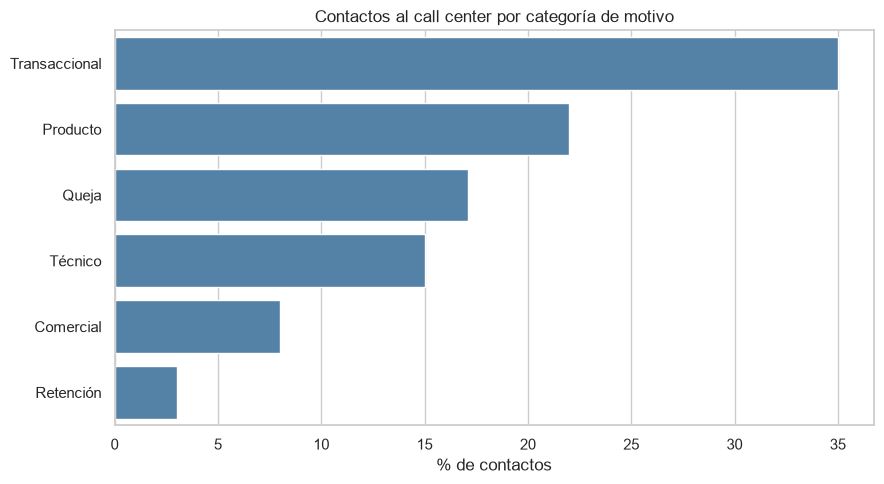

In [32]:
# gráfico de categorías
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=categorias, y="reason_category", x="pct", ax=ax, color="steelblue")
ax.set(title="Contactos al call center por categoría de motivo", xlabel="% de contactos", ylabel="")
plt.tight_layout()

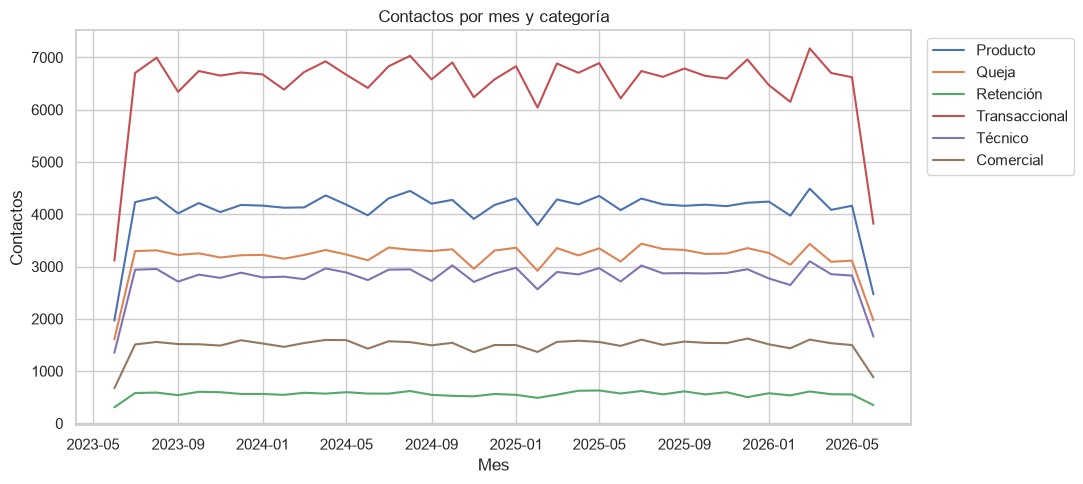

In [33]:
# tendencia mensual por categoría
mensual = q("""
    SELECT DATE_TRUNC('month', CAST(interaction_date AS DATE)) AS mes, reason_category, COUNT(*) AS n
    FROM call_center_interactions
    GROUP BY 1, 2
    ORDER BY 1
""")
fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=mensual, x="mes", y="n", hue="reason_category", ax=ax)
ax.set(title="Contactos por mes y categoría", xlabel="Mes", ylabel="Contactos")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()

In [34]:
# cortes por país, segmento y canal
def corte(columna, origen="c"):
    df = q(f"""
        SELECT {origen}.{columna} AS grupo, i.reason_category, COUNT(*) AS n
        FROM call_center_interactions i
        LEFT JOIN customers c USING (customer_id)
        GROUP BY 1, 2
    """)
    tabla = df.pivot_table(index="grupo", columns="reason_category", values="n", fill_value=0)
    return (100 * tabla.div(tabla.sum(axis=1), axis=0)).round(1)

for col, origen in [("country", "c"), ("segment", "c"), ("channel", "i")]:  # AJUSTAR nombres
    print(f"\n### Por {col} (% por fila)")
    try:
        display(corte(col, origen))
    except Exception as e:
        print("  ", str(e)[:100])


### Por country (% por fila)


reason_category,Comercial,Producto,Queja,Retención,Transaccional,Técnico
grupo,,,,,,
Argentina,7.9,22.0,17.2,3.0,35.0,15.0
Colombia,8.0,22.0,17.0,3.0,35.1,14.9
México,8.1,22.0,17.0,3.0,34.9,15.1



### Por segment (% por fila)


reason_category,Comercial,Producto,Queja,Retención,Transaccional,Técnico
grupo,,,,,,
Basic,8.0,22.0,17.1,3.0,35.0,14.9
Plus,8.0,21.9,17.1,3.0,35.0,15.0
Premium,7.9,21.7,16.9,3.0,35.1,15.3
Student,8.1,22.2,16.8,3.0,34.8,15.2



### Por channel (% por fila)


reason_category,Comercial,Producto,Queja,Retención,Transaccional,Técnico
grupo,,,,,,
App,8.0,22.3,16.7,3.0,35.2,14.9
Email,7.9,22.1,16.8,3.2,34.8,15.1
Phone,8.0,22.0,17.1,3.0,35.0,15.0
Web,8.2,20.6,17.3,3.2,35.0,15.6
Web Chat,8.3,21.8,17.3,3.0,35.0,14.6
WhatsApp,8.2,21.8,17.0,3.1,34.8,15.2


In [35]:
# quejas: tipo, categoría, canal de recepción
for col in ["case_type", "category", "reception_channel"]:
    display(q(f"""
        SELECT {col}, COUNT(*) AS n, ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
        FROM complaints GROUP BY 1 ORDER BY n DESC
    """))

q("""
    SELECT category, subcategory, COUNT(*) AS n,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM complaints GROUP BY 1, 2 ORDER BY n DESC LIMIT 25
""")

,case_type,n,pct
0,Complaint,40452,60.3
1,Claim,16598,24.7
2,Request,6761,10.1
3,Suggestion,3284,4.9


,category,n,pct
0,Transactions,13580,20.2
1,Fees,13553,20.2
2,Technical,13407,20.0
3,Branch,13361,19.9
4,Service,13194,19.7


,reception_channel,n,pct
0,Call Center,33761,50.3
1,Email,13323,19.9
2,Web,9884,14.7
3,App,6727,10.0
4,Branch,2683,4.0
5,Regulator,717,1.1


,category,subcategory,n,pct
0,Transactions,Cargo no reconocido,12297,18.3
1,Fees,Cobro indebido,12194,18.2
2,Technical,Problema con app,12128,18.1
3,Branch,Atención en sucursal,11892,17.7
4,Service,Calidad de servicio,11886,17.7
5,Branch,NaN,1469,2.2
6,Fees,NaN,1359,2.0
7,Service,NaN,1308,1.9
8,Transactions,NaN,1283,1.9
9,Technical,NaN,1279,1.9


### Hallazgos · Sección 3
- **Top 3 motivos**: Transaccional **35,0 %**, Producto **22,0 %**, Queja **17,1 %** (luego Técnico 15 %, Comercial 8 %, Retención 3 %). Solo hay 6 categorías y `contact_reason` repite `reason_category`: no hay motivos más finos (no existe "tarjeta" ni "crédito" como motivo).
- **Sin estacionalidad**: la serie mensual es plana (bajas en febrero por ser mes corto; los extremos son meses parciales). 2024 y 2025 tienen casi el mismo volumen.
- **Sin diferencias por país, segmento ni canal**: cada categoría varía ≤ 1,4 pp entre grupos. No hay un subgrupo que justifique un flujo especializado.
- **Quejas**: 60 % son `Complaint` y 25 % `Claim`; 50 % entra por call center. Las 5 categorías pesan ~20 % cada una. Las dos subcategorías de dinero, **"Cargo no reconocido" (18,3 %) y "Cobro indebido" (18,2 %), suman 36,5 %** de todas las quejas.

## Sección 4 · Dolor operativo por motivo

In [50]:
dolor = q("""
    SELECT reason_category, contact_reason,
           COUNT(*)                                             AS n,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1)   AS pct,
           ROUND(100.0 * AVG(was_resolved::INT), 1)             AS fcr_pct,
           ROUND(100.0 * AVG(was_escalated::INT), 1)            AS escalamiento_pct,
           ROUND(100.0 * AVG(requires_followup::INT), 1)        AS seguimiento_pct,
           ROUND(MEDIAN(duration_seconds) / 60, 1)              AS aht_mediana_min,
           ROUND(MEDIAN(wait_time_seconds) / 60, 1)             AS espera_mediana_min,
           ROUND(100.0 * AVG((detected_sentiment IN ('Negativo', 'Muy Negativo'))::INT), 1) AS negativo_pct
    FROM call_center_interactions
    GROUP BY 1, 2
    ORDER BY n DESC
""")

total = q("""
    SELECT ROUND(100.0 * AVG(was_resolved::INT), 1)      AS fcr_pct,
           ROUND(100.0 * AVG(was_escalated::INT), 1)     AS escalamiento_pct,
           ROUND(100.0 * AVG(requires_followup::INT), 1) AS seguimiento_pct,
           ROUND(MEDIAN(duration_seconds) / 60, 1)       AS aht_mediana_min
    FROM call_center_interactions
""").iloc[0]
print("Promedio general:", total.to_dict())

# Cuántos indicadores están peor que el promedio (sirve para el criterio 2 de la matriz)
dolor["peor_en"] = (
    (dolor["fcr_pct"] < total["fcr_pct"]).astype(int)
    + (dolor["escalamiento_pct"] > total["escalamiento_pct"]).astype(int)
    + (dolor["seguimiento_pct"] > total["seguimiento_pct"]).astype(int)
    + (dolor["aht_mediana_min"] > total["aht_mediana_min"]).astype(int)
)
dolor

Promedio general: {'fcr_pct': 76.6, 'escalamiento_pct': 10.0, 'seguimiento_pct': 34.8, 'aht_mediana_min': 4.9}


,reason_category,contact_reason,n,pct,fcr_pct,escalamiento_pct,seguimiento_pct,aht_mediana_min,espera_mediana_min,negativo_pct,peor_en
0,Transaccional,Transaccional,240056,35.0,91.5,9.9,22.1,3.4,2.0,0.0,0
1,Producto,Producto,150863,22.0,89.6,10.0,23.8,4.4,2.0,19.2,0
2,Queja,Queja,117021,17.1,43.6,10.0,63.0,7.2,2.0,34.9,3
3,Técnico,Técnico,102899,15.0,69.9,10.1,40.6,6.0,2.0,35.0,4
4,Comercial,Comercial,54879,8.0,65.2,9.8,44.5,9.0,2.0,34.9,3
5,Retención,Retención,20578,3.0,60.2,9.8,49.1,8.0,2.0,34.9,3


In [37]:
# agregado por categoría 
q("""
    SELECT reason_category,
           COUNT(*) AS n,
           ROUND(100.0 * AVG(was_resolved::INT), 1)      AS fcr_pct,
           ROUND(100.0 * AVG(was_escalated::INT), 1)     AS escalamiento_pct,
           ROUND(100.0 * AVG(requires_followup::INT), 1) AS seguimiento_pct,
           ROUND(MEDIAN(duration_seconds) / 60, 1)       AS aht_mediana_min
    FROM call_center_interactions
    GROUP BY 1 ORDER BY n DESC
""")

,reason_category,n,fcr_pct,escalamiento_pct,seguimiento_pct,aht_mediana_min
0,Transaccional,240056,91.5,9.9,22.1,3.4
1,Producto,150863,89.6,10.0,23.8,4.4
2,Queja,117021,43.6,10.0,63.0,7.2
3,Técnico,102899,69.9,10.1,40.6,6.0
4,Comercial,54879,65.2,9.8,44.5,9.0
5,Retención,20578,60.2,9.8,49.1,8.0


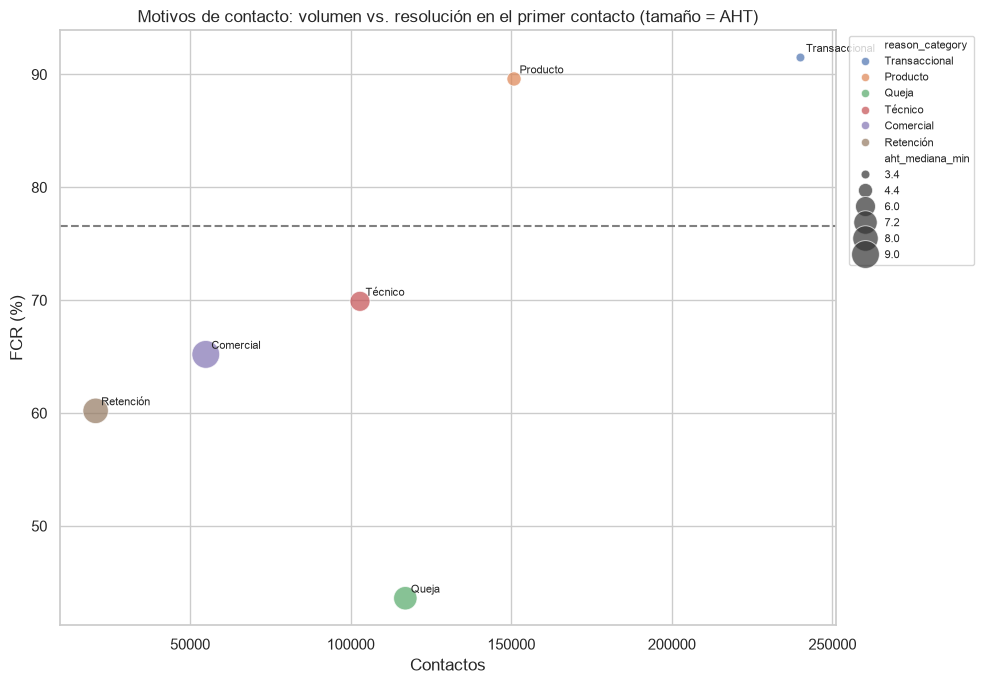

In [38]:
# volumen vs resolución
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(data=dolor, x="n", y="fcr_pct", size="aht_mediana_min", hue="reason_category",
                sizes=(40, 400), alpha=0.7, ax=ax)
for _, r in dolor.nlargest(12, "n").iterrows():
    ax.annotate(r["contact_reason"], (r["n"], r["fcr_pct"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.axhline(total["fcr_pct"], ls="--", c="gray")
ax.set(title="Motivos de contacto: volumen vs. resolución en el primer contacto (tamaño = AHT)",
       xlabel="Contactos", ylabel="FCR (%)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()

In [ ]:
q("""
    SELECT category,
           COUNT(*) AS n,
           ROUND(100.0 * AVG(sla_breached::INT), 1)                               AS sla_incumplido_pct,
           MEDIAN(resolution_days)                                                AS resolucion_mediana_dias,
           ROUND(100.0 * AVG(COALESCE(compensation_granted > 0, FALSE)::INT), 1)  AS con_compensacion_pct,
           ROUND(MEDIAN(compensation_granted), 1)                                 AS compensacion_mediana,
           ROUND(AVG(resolution_satisfaction), 2)                                 AS satisfaccion_media,
           ROUND(100.0 * AVG(is_repeat_complainer::INT), 1)                       AS reincidente_pct
    FROM complaints
    GROUP BY 1 ORDER BY n DESC
""")

In [42]:
# CSAT por categoría de motivo
q("""
    SELECT i.reason_category,
           COUNT(*) AS encuestas,
           ROUND(AVG(s.main_score), 2) AS csat_medio   -- AJUSTAR nombre de la columna de puntaje
    FROM satisfaction_surveys s
    JOIN call_center_interactions i USING (interaction_id)
    GROUP BY 1 ORDER BY csat_medio
""")

,reason_category,encuestas,csat_medio
0,Queja,36357,3.00
1,Retención,6355,3.26
2,Comercial,17147,3.35
3,Técnico,31802,3.42
4,Producto,46566,3.74
5,Transaccional,74532,3.76


### Hallazgos · Sección 4
- **Queja es el motivo con más dolor y volumen alto** (117k contactos, 17 %): **FCR 43,6 %** vs. 76,6 % promedio (el peor), **seguimiento 63 %** vs. 34,8 %, AHT **7,2 min** vs. 4,9, **CSAT 3,00** (el más bajo), 35 % sentimiento negativo.
- Transaccional (el de más volumen) es el que mejor funciona: FCR 91,5 %, AHT 3,4 min, 0 % negativo. Automatizarlo ahorra poco dolor.
- El escalamiento es **10 % en todos los motivos** y la espera mediana es **2 min en todos**: esas dos métricas no discriminan.
- Quejas formales: **20 % incumple SLA**, resolución mediana **16 días** (p90 = 28), solo **6,9 % recibe compensación** (mediana ~USD 252), satisfacción de resolución ~3,0/5 y 15 % son reincidentes. Iguales en todas las categorías y países.

## Sección 5 · ¿Los datos soportan cada flujo?

### Disputas de transacciones

In [43]:
# estado, tipo, fraude y comercio
display(q("""
    SELECT transaction_type, transaction_status, COUNT(*) AS n,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM transactions GROUP BY 1, 2 ORDER BY n DESC
"""))

q("""
    SELECT COUNT(*) AS transacciones,
           ROUND(100.0 * AVG(is_fraud::INT), 2)                   AS fraude_pct,
           ROUND(100.0 * AVG((merchant_name IS NOT NULL)::INT), 1) AS con_comercio_pct,
           COUNT(DISTINCT merchant_name)                          AS comercios_distintos
    FROM transactions
""")

,transaction_type,transaction_status,n,pct
0,Purchase,Approved,321276,22.5
1,Withdrawal,Approved,287302,20.1
2,Transfer,Approved,266359,18.6
3,Payment,Approved,219363,15.3
4,Deposit,Approved,181753,12.7
5,Adjustment,Approved,39187,2.7
6,Purchase,Declined,17611,1.2
7,Withdrawal,Declined,15475,1.1
8,Transfer,Declined,14543,1.0
9,Payment,Declined,11981,0.8


,transacciones,fraude_pct,con_comercio_pct,comercios_distintos
0,1429456,0.09,23.2,24


,transaction_type,p25,mediana,p90,p99,maximo
0,Adjustment,262.28,505.22,902.40,991.37,999.80
1,Payment,538.30,1027.66,1806.66,1981.67,2000.00
2,Transfer,2581.11,5074.53,9006.53,9897.94,9999.79
3,Withdrawal,138.57,259.28,451.95,495.32,500.00
4,Purchase,128.81,252.74,450.23,495.14,500.00
5,Deposit,1298.22,2535.85,4504.06,4949.76,4999.96


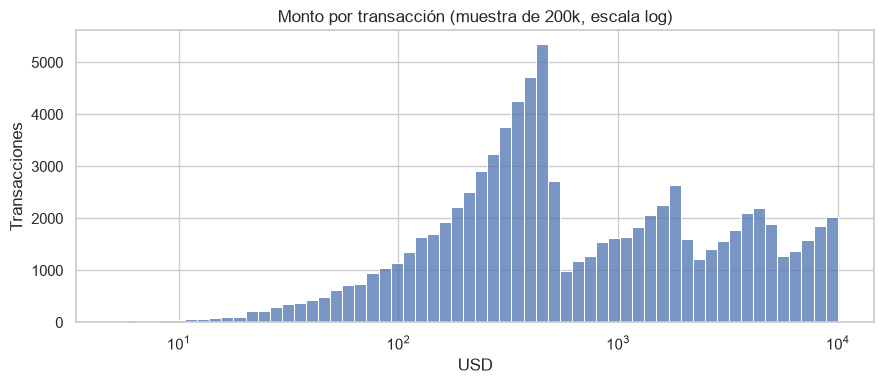

In [44]:
# distribución de montos
display(q("""
    SELECT transaction_type,
           ROUND(QUANTILE_CONT(amount_usd, 0.25), 2) AS p25,
           ROUND(MEDIAN(amount_usd), 2)              AS mediana,
           ROUND(QUANTILE_CONT(amount_usd, 0.9), 2)  AS p90,
           ROUND(QUANTILE_CONT(amount_usd, 0.99), 2) AS p99,
           ROUND(MAX(amount_usd), 2)                 AS maximo
    FROM transactions GROUP BY 1
"""))

montos = q("SELECT amount_usd FROM transactions USING SAMPLE 200000 ROWS (reservoir, 42)")
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(montos["amount_usd"].clip(lower=0.01), log_scale=True, bins=60, ax=ax)
ax.set(title="Monto por transacción (muestra de 200k, escala log)", xlabel="USD", ylabel="Transacciones")
plt.tight_layout()

In [ ]:
# ¿Se pueden emparejar quejas con transacciones?
# claimed_amount viene en la moneda de la queja: se compara con amount (moneda local) + currency, no con amount_usd
emparejo = q("""
    WITH quejas AS (
        SELECT complaint_id, customer_id, affected_product_id, claimed_amount, currency,
               CAST(creation_date AS DATE) AS fecha_queja
        FROM complaints
        WHERE CAST(creation_date AS DATE) >= DATE '2025-08-01'           -- ventana cubierta por transactions_12m
          AND claimed_amount IS NOT NULL
    ),
    candidatos AS (
        SELECT q.complaint_id, COUNT(t.transaction_id) AS n_candidatas
        FROM quejas q
        LEFT JOIN transactions t
          ON t.customer_id = q.customer_id
         AND t.product_id = q.affected_product_id
         AND t.currency = q.currency
         AND ABS(t.amount - q.claimed_amount) <= 0.01 * q.claimed_amount + 0.5
         AND CAST(t.transaction_date AS DATE) BETWEEN q.fecha_queja - INTERVAL 60 DAY AND q.fecha_queja
        GROUP BY 1
    )
    SELECT CASE WHEN n_candidatas = 0 THEN '0 (no empareja)'
                WHEN n_candidatas = 1 THEN '1 (emparejo único)'
                ELSE '2+ (ambiguo)' END AS resultado,
           COUNT(*) AS quejas,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM candidatos GROUP BY 1 ORDER BY 1
""")
emparejo

In [ ]:
# Chunk 5a.4 · Ambigüedad natural: si el cliente no da el monto, ¿cuántas transacciones candidatas hay?
q("""
    WITH quejas AS (
        SELECT complaint_id, customer_id, CAST(creation_date AS DATE) AS fq
        FROM complaints WHERE CAST(creation_date AS DATE) >= DATE '2025-08-01'
    ),
    c AS (
        SELECT q.complaint_id, COUNT(t.transaction_id) AS n
        FROM quejas q LEFT JOIN transactions t
          ON t.customer_id = q.customer_id
         AND CAST(t.transaction_date AS DATE) BETWEEN q.fq - INTERVAL 60 DAY AND q.fq
        GROUP BY 1
    )
    SELECT CASE WHEN n = 0 THEN '0' WHEN n = 1 THEN '1 (único)' ELSE '2+ (hay que aclarar)' END AS candidatas,
           COUNT(*) AS quejas, ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM c GROUP BY 1 ORDER BY 1
""")

In [ ]:
# Chunk 5a.5 · ¿fraud_score sirve como señal para escalar?
display(q("""
    SELECT is_fraud, COUNT(*) AS n, ROUND(100.0 * AVG((fraud_score IS NULL)::INT), 1) AS score_nulo_pct,
           ROUND(MEDIAN(fraud_score), 1) AS score_mediana, ROUND(MAX(fraud_score), 1) AS score_max
    FROM transactions GROUP BY 1
"""))
from sklearn.metrics import roc_auc_score
fs = q("SELECT is_fraud::INT AS y, fraud_score FROM transactions WHERE fraud_score IS NOT NULL")
print("AUC de fraud_score para is_fraud:", round(roc_auc_score(fs["y"], fs["fraud_score"]), 3))

### Soporte de tarjetas

In [48]:
# Productos de tarjeta por estado
q("""
    SELECT product_type, product_status, COUNT(*) AS n,                   -- AJUSTAR product_type
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY product_type), 1) AS pct_del_tipo
    FROM products
    WHERE product_type ILIKE 'Tarjeta%'
    GROUP BY 1, 2 ORDER BY 1, n DESC
""")

,product_type,product_status,n,pct_del_tipo
0,Tarjeta Crédito,Active,85090,85.0
1,Tarjeta Crédito,Closed,8053,8.0
2,Tarjeta Crédito,Blocked,4932,4.9
3,Tarjeta Crédito,Suspended,2027,2.0
4,Tarjeta Débito,Active,33749,84.5
5,Tarjeta Débito,Closed,3244,8.1
6,Tarjeta Débito,Blocked,2112,5.3
7,Tarjeta Débito,Suspended,833,2.1


In [51]:
# Transacciones rechazadas por ​response_code​: ¿tienen sentido?
display(q("""
    SELECT response_code, COUNT(*) AS n,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM transactions
    WHERE transaction_status = 'Declined'
    GROUP BY 1 ORDER BY n DESC
"""))

# Prueba de coherencia: si los códigos fueran aleatorios, se verían igual en aprobadas y rechazadas
q("""
    SELECT transaction_status, response_code, COUNT(*) AS n
    FROM transactions
    GROUP BY 1, 2
    ORDER BY 1, n DESC
""").pivot_table(index="response_code", columns="transaction_status", values="n", fill_value=0)

,response_code,n,pct
0,14,17113,24.0
1,51,17078,23.9
2,54,16966,23.7
3,05,16778,23.5
4,NaN,3516,4.9


transaction_status,Approved,Declined,Pending,Reversed
response_code,,,,
00,1249512.0,0.0,0.0,0.0
05,0.0,16778.0,6786.0,3424.0
14,0.0,17113.0,6873.0,3337.0
51,0.0,17078.0,6773.0,3302.0
54,0.0,16966.0,6633.0,3467.0


In [53]:
# ¿Los rechazos se relacionan con el estado del producto?
q("""
    SELECT p.product_status,
           COUNT(*) AS transacciones,
           ROUND(100.0 * AVG((t.transaction_status = 'Declined')::INT), 1) AS rechazo_pct
    FROM transactions t
    JOIN products p USING (product_id)
    WHERE p.product_type ILIKE 'Tarjeta%'
    GROUP BY 1 ORDER BY rechazo_pct DESC
""")

,product_status,transacciones,rechazo_pct
0,Active,499099,5.0


In [ ]:
# Chunk 5b.4 · ¿El código 54 (tarjeta vencida) coincide con expiration_date? ¿El 51 (fondos insuficientes) con el cupo?
q("""
    SELECT t.transaction_status, t.response_code, COUNT(*) AS n,
           ROUND(100.0 * AVG((p.expiration_date < CAST(t.transaction_date AS DATE))::INT), 1) AS tarjeta_vencida_pct,
           ROUND(100.0 * AVG(CASE WHEN p.product_type = 'Tarjeta Crédito'
                                  THEN (t.amount > p.credit_limit - p.current_balance)::INT END), 1) AS excede_cupo_pct
    FROM transactions t JOIN products p USING (product_id)
    WHERE p.product_type ILIKE 'Tarjeta%'
    GROUP BY 1, 2 ORDER BY 1, 2
""")

### Consultas de cuenta y pagos

In [54]:
# Lista de todos los motivos
q("SELECT reason_category, contact_reason, COUNT(*) AS n FROM call_center_interactions GROUP BY 1, 2 ORDER BY 1, n DESC")

,reason_category,contact_reason,n
0,Comercial,Comercial,54879
1,Producto,Producto,150863
2,Queja,Queja,117021
3,Retención,Retención,20578
4,Transaccional,Transaccional,240056
5,Técnico,Técnico,102899


In [55]:
# ¿Tenemos lo necesario para responder saldo y "¿ya se acreditó?"?
display(q("""
    SELECT product_type,
           COUNT(*) AS productos,
           ROUND(100.0 * AVG((current_balance IS NULL)::INT), 1)        AS balance_nulo_pct,
           ROUND(100.0 * AVG((last_transaction_date IS NULL)::INT), 1)  AS ult_transaccion_nula_pct
    FROM products GROUP BY 1
"""))

# Coherencia: ¿last_transaction_date coincide con la última transacción real del producto?
q("""
    WITH ult AS (
        SELECT product_id, MAX(CAST(transaction_date AS DATE)) AS ult_real
        FROM transactions GROUP BY 1
    )
    SELECT COUNT(*) AS productos_con_transacciones,
           ROUND(100.0 * AVG((CAST(p.last_transaction_date AS DATE) = u.ult_real)::INT), 1) AS coincide_pct,
           MEDIAN(ABS(DATE_DIFF('day', CAST(p.last_transaction_date AS DATE), u.ult_real))) AS dif_mediana_dias
    FROM products p JOIN ult u USING (product_id)
""")

,product_type,productos,balance_nulo_pct,ult_transaccion_nula_pct
0,Préstamo Personal,19960,0.0,23.2
1,Préstamo Hipotecario,11910,0.0,23.7
2,Inversión,5859,0.0,23.1
3,Tarjeta Crédito,100102,0.0,23.6
4,Seguro,2049,0.0,23.3
5,Cuenta Corriente,99979,0.0,23.5
6,Cuenta Ahorro,120203,0.0,23.5
7,Tarjeta Débito,39938,0.0,24.1


,productos_con_transacciones,coincide_pct,dif_mediana_dias
0,334959,0.1,475.0


In [56]:
# Pagos y sus estados

q("""
    SELECT transaction_type, transaction_status, COUNT(*) AS n
    FROM transactions
    WHERE transaction_type ILIKE '%payment%' OR transaction_type ILIKE '%transfer%' OR transaction_type ILIKE '%deposit%'
    GROUP BY 1, 2 ORDER BY 1, n DESC
""")

,transaction_type,transaction_status,n
0,Deposit,Approved,181753
1,Deposit,Declined,9680
2,Deposit,Pending,3969
3,Deposit,Reversed,1958
4,Payment,Approved,219363
5,Payment,Declined,11981
6,Payment,Pending,4723
7,Payment,Reversed,2407
8,Transfer,Approved,266359
9,Transfer,Declined,14543


### Crédito

In [57]:
# Nulos y distribución de las variables de crédito
display(q("""
    SELECT COUNT(*) AS clientes,
           ROUND(100.0 * AVG((credit_score IS NULL)::INT), 1)              AS score_nulo_pct,
           ROUND(100.0 * AVG((estimated_monthly_income IS NULL)::INT), 1)  AS ingreso_nulo_pct,
           MIN(credit_score) AS score_min, MEDIAN(credit_score) AS score_mediana, MAX(credit_score) AS score_max,
           MEDIAN(estimated_monthly_income) AS ingreso_mediana
    FROM customers
"""))

q("""
    SELECT product_type, COUNT(*) AS n,
           ROUND(100.0 * AVG((credit_limit IS NULL)::INT), 1)  AS limite_nulo_pct,
           ROUND(100.0 * AVG((interest_rate IS NULL)::INT), 1) AS tasa_nula_pct,
           ROUND(100.0 * AVG((days_past_due > 0)::INT), 1)     AS con_mora_pct,
           ROUND(100.0 * AVG((days_past_due > 30)::INT), 1)    AS mora_30_pct
    FROM products
    WHERE credit_limit IS NOT NULL OR days_past_due IS NOT NULL
    GROUP BY 1
""")

,clientes,score_nulo_pct,ingreso_nulo_pct,score_min,score_mediana,score_max,ingreso_mediana
0,150000,15.0,20.0,422.0,631.0,850.0,342974.42


,product_type,n,limite_nulo_pct,tasa_nula_pct,con_mora_pct,mora_30_pct
0,Tarjeta Crédito,99874,4.8,10.0,14.9,10.0
1,Préstamo Hipotecario,11884,4.9,10.1,15.2,10.2
2,Préstamo Personal,19920,4.8,10.1,15.0,9.9


Correlación de Spearman score vs. días de mora: -0.006


,clientes,score_medio,mora_30_pct
decil_score,,,
1,7427,539.982496,14.9
2,7303,572.668766,14.5
3,7410,591.289339,13.8
4,6880,606.995640,13.6
5,7265,622.841432,14.8
6,7200,641.571389,13.7
7,7293,665.626491,14.2
8,7094,694.953623,14.0
9,7251,733.422838,14.4


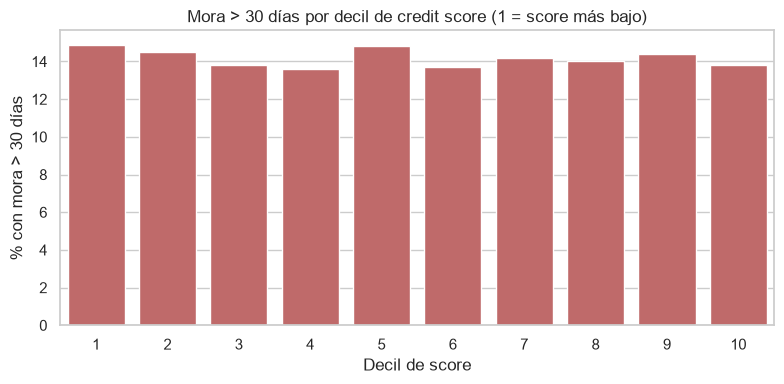

In [58]:
# Prueba de realismo: ¿el score predice la mora?
credito = q("""
    SELECT c.customer_id, c.credit_score, c.estimated_monthly_income,
           MAX(p.days_past_due) AS max_dpd
    FROM customers c
    JOIN products p USING (customer_id)
    WHERE c.credit_score IS NOT NULL AND p.days_past_due IS NOT NULL
    GROUP BY 1, 2, 3
""")
credito["mora_30"] = (credito["max_dpd"] > 30).astype(int)
credito["decil_score"] = pd.qcut(credito["credit_score"], 10, labels=False, duplicates="drop") + 1

print("Correlación de Spearman score vs. días de mora:",
      round(credito[["credit_score", "max_dpd"]].corr(method="spearman").iloc[0, 1], 3))

por_decil = credito.groupby("decil_score").agg(clientes=("customer_id", "count"),
                                                score_medio=("credit_score", "mean"),
                                                mora_30_pct=("mora_30", "mean"))
por_decil["mora_30_pct"] = (100 * por_decil["mora_30_pct"]).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=por_decil.reset_index(), x="decil_score", y="mora_30_pct", color="indianred", ax=ax)
ax.set(title="Mora > 30 días por decil de credit score (1 = score más bajo)", xlabel="Decil de score", ylabel="% con mora > 30 días")
plt.tight_layout()
por_decil

### Hallazgos · Sección 5 (criterio 3, soporte de los datos)

**5a · Disputas → 2 (supuestos menores).**
- `transactions` trae todo lo necesario para buscar y evaluar un cargo: cliente, producto, monto y moneda, fecha, canal, estado (hay 0,9 % `Reversed` y 2,1 % `Pending`), comercio (23 % de las filas, 24 comercios), país (5 % en el extranjero) y `is_fraud`/`fraud_score`.
- `fraud_score` **sí separa el fraude** (AUC 0,84; ninguna transacción legítima pasa de 30, la mediana del fraude es 49), aunque es nulo en el 20 %. Es la única señal estructurada coherente del dataset.
- **Supuesto**: las quejas no se pueden emparejar con transacciones (0 % con cliente + producto + moneda + monto; 0 % con cliente + producto). La política y los casos de prueba se construyen desde `transactions`, y `complaints` se usa como plantilla del caso (tipo, categoría, prioridad, SLA) y como línea base de desempeño.
- Si el cliente no da el monto, el **44 % de los casos tiene 2 o más transacciones candidatas** en 60 días: la aclaración aparece de forma natural.

**5b · Tarjetas → 2.**
- `product_status` es coherente: las tarjetas `Blocked`, `Suspended` y `Closed` tienen **0 transacciones**; bloquear/desbloquear se puede modelar con datos reales.
- Pero los `response_code` no significan nada: 00 = aprobada, y 05/14/51/54 salen **~25 % cada uno** en rechazos, pendientes y reversos, sin relación con el cupo (51) ni con el vencimiento (54). El rechazo es 5 % plano. "Explicar un rechazo" sería traducir el código, no diagnosticarlo.
- No existe un motivo de contacto "tarjetas": el volumen no se puede medir.

**5c · Cuenta y pagos → 2.**
- Saldo sin nulos, pagos/transferencias con estados `Pending` y `Reversed` ("¿ya se acreditó?"). Pero `last_transaction_date` es incoherente (0,1 % coincide) y habría que recalcularla. Casi solo lectura.

**5d · Crédito → 1 (veto).**
- `credit_score` **no predice la mora**: Spearman −0,006 y la mora > 30 días es ~14 % en los 10 deciles (14,9 % en el más bajo, 13,8 % en el más alto). Cualquier "estimación de riesgo" sería ruido, y no hay solicitudes de crédito ni motivo de contacto de crédito (Comercial es 8 %).

## Sección 6 · Idioma y texto

In [59]:
# Idioma, acento y calidad de la transcripción
for col in ["detected_language", "detected_accent", "transcription_model", "audio_quality"]:
    try:
        display(q(f"""
            SELECT {col}, COUNT(*) AS n, ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
            FROM call_transcripts GROUP BY 1 ORDER BY n DESC
        """))
    except Exception as e:
        print(col, "→", str(e)[:80])

q("SELECT ROUND(AVG(accent_confidence), 3) AS confianza_media, ROUND(MEDIAN(accent_confidence), 3) AS confianza_mediana FROM call_transcripts")

,detected_language,n,pct
0,es,171321,100.0


,detected_accent,n,pct
0,NaN,63083,36.8
1,mexican,54152,31.6
2,colombian,32284,18.8
3,argentine,21802,12.7


,transcription_model,n,pct
0,AWS Transcribe,43117,25.2
1,Whisper v3,42803,25.0
2,Google STT,42740,24.9
3,Azure Speech,42661,24.9


,audio_quality,n,pct
0,High,114371,66.8
1,Medium,40350,23.6
2,NaN,8638,5.0
3,Low,7962,4.6


,confianza_media,confianza_mediana
0,0.87,0.87


In [60]:
# Largo del texto del cliente
q("""
    SELECT COUNT(*) AS transcripts,
           ROUND(100.0 * AVG((customer_text IS NULL OR TRIM(customer_text) = '')::INT), 1) AS vacio_pct,
           MEDIAN(LEN(STRING_SPLIT(customer_text, ' ')))                   AS palabras_mediana,
           QUANTILE_CONT(LEN(STRING_SPLIT(customer_text, ' ')), 0.9)       AS palabras_p90,
           COUNT(DISTINCT customer_text)                                    AS textos_distintos
    FROM call_transcripts
""")

,transcripts,vacio_pct,palabras_mediana,palabras_p90,textos_distintos
0,171321,0.0,15.0,24.0,42


In [ ]:
# Lectura humana: 10 textos al azar de cada uno de los 3 motivos principales
# Ojo: en DuckDB USING SAMPLE se aplica ANTES del WHERE; por eso se filtra en una subconsulta y luego se muestrea
top3 = motivos.head(3)["contact_reason"].tolist()
for motivo in top3:
    print(f"\n{'=' * 100}\nMOTIVO: {motivo}\n{'=' * 100}")
    muestra = q(f"""
        SELECT customer_text FROM (
            SELECT t.customer_text
            FROM call_transcripts t JOIN call_center_interactions i USING (interaction_id)
            WHERE i.contact_reason = '{motivo.replace("'", "''")}' AND t.customer_text IS NOT NULL
        ) USING SAMPLE 10 ROWS (reservoir, 42)
    """)
    for i, txt in enumerate(muestra["customer_text"], 1):
        print(f"\n[{i}] {txt[:600]}")

### Hallazgos · Sección 6
- **No hay portugués**: `detected_language` = `es` en el 100 % de los 171k transcripts. Es una limitación a reportar; el portugués de la demo vendrá de nuestro propio set de evaluación.
- El texto es de **plantilla**: 171k transcripts tienen solo **42 `customer_text` distintos** (mediana de 15 palabras) y todos piden **el saldo** ("Quisiera saber cuál es mi saldo actual en mi cuenta de ahorros").
- **El texto no habla del motivo etiquetado**: el mismo texto aparece en las 6 categorías con las mismas proporciones de la población (35 % Transaccional, 17 % Queja, 15 % Técnico). Ejemplos que no cuadran: *"necesito consultar el saldo de mi tarjeta de crédito"* etiquetado como **Queja** y como **Técnico**. Ejemplo que sí: el mismo texto como **Transaccional**. Cuadra solo por azar.
- Acentos: mexicano 32 %, colombiano 19 %, argentino 13 %, nulo 37 %; 4 motores de transcripción al 25 % cada uno. `detected_intents` es siempre `consulta_general`.

## Sección 7 · Viabilidad de ML

In [62]:
# Datos para la prueba
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import make_pipeline

df = q("""
    SELECT i.customer_id, t.customer_text, t.full_text, i.contact_reason, i.reason_category
    FROM call_transcripts t
    JOIN call_center_interactions i USING (interaction_id)
    WHERE t.customer_text IS NOT NULL
    USING SAMPLE 30000 ROWS (reservoir, 42)
""").drop_duplicates()

split = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED)
tr, te = next(split.split(df, groups=df["customer_id"]))  # un cliente no aparece en train y test a la vez
print(len(df), "filas ·", len(tr), "train ·", len(te), "test")

29874 filas · 22369 train · 7505 test


In [63]:
# Baseline vs. TF-IDF, con dos etiquetas y dos textos
def modelo_tfidf():
    return make_pipeline(
        TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=3, sublinear_tf=True),
        LogisticRegression(max_iter=2000, class_weight="balanced"),
    )

resultados = []
for etiqueta in ["reason_category", "contact_reason"]:
    y = df[etiqueta]
    dummy = DummyClassifier(strategy="stratified", random_state=SEED).fit(df.iloc[tr], y.iloc[tr])
    fila = {"etiqueta": etiqueta, "clases": y.nunique(),
            "azar": f1_score(y.iloc[te], dummy.predict(df.iloc[te]), average="macro")}
    for texto in ["customer_text", "full_text"]:  # full_text solo para detectar fuga
        m = modelo_tfidf().fit(df[texto].iloc[tr], y.iloc[tr])
        fila[f"tfidf_{texto}"] = f1_score(y.iloc[te], m.predict(df[texto].iloc[te]), average="macro")
    resultados.append(fila)
pd.DataFrame(resultados).round(3)

,etiqueta,clases,azar,tfidf_customer_text,tfidf_full_text
0,reason_category,6,0.161,0.124,0.114
1,contact_reason,6,0.161,0.124,0.114


In [64]:
# Detalle por clase
y = df["reason_category"]
m = modelo_tfidf().fit(df["customer_text"].iloc[tr], y.iloc[tr])
print(classification_report(y.iloc[te], m.predict(df["customer_text"].iloc[te]), digits=3))

               precision    recall  f1-score   support

    Comercial      0.071     0.107     0.085       617
     Producto      0.220     0.340     0.267      1648
        Queja      0.180     0.309     0.227      1294
    Retención      0.025     0.142     0.042       218
Transaccional      0.346     0.075     0.123      2560
      Técnico      0.000     0.000     0.000      1168

     accuracy                          0.166      7505
    macro avg      0.140     0.162     0.124      7505
 weighted avg      0.204     0.166     0.148      7505



/Users/arielamishaancohen/Documents/Después/1 Proyectos UVG/4 Hackathon Factored/factored-hackathon-2026-daia/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/arielamishaancohen/Documents/Después/1 Proyectos UVG/4 Hackathon Factored/factored-hackathon-2026-daia/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/arielamishaancohen/Documents/Después/1 Proyectos UVG/4 Hackathon Factored/factored-hackathon-2026-daia/.venv/lib/python3.13/site-packages/

In [ ]:
# Chunk 7.4 · Quejas: description → category
dq = q("""
    SELECT customer_id, description, category FROM complaints
    WHERE description IS NOT NULL
    USING SAMPLE 30000 ROWS (reservoir, 42)
""").dropna(subset=["description"])
print("descripciones distintas en la muestra:", dq["description"].nunique())
tr2, te2 = next(GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED).split(dq, groups=dq["customer_id"]))
dummy = DummyClassifier(strategy="stratified", random_state=SEED).fit(dq.iloc[tr2], dq["category"].iloc[tr2])
m = modelo_tfidf().fit(dq["description"].iloc[tr2], dq["category"].iloc[tr2])
print("Azar:  ", round(f1_score(dq["category"].iloc[te2], dummy.predict(dq.iloc[te2]), average="macro"), 3))
print("TF-IDF:", round(f1_score(dq["category"].iloc[te2], m.predict(dq["description"].iloc[te2]), average="macro"), 3))

In [ ]:
# Chunk 7.5 · Variables estructuradas: ¿se puede predecir el escalamiento?
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

de = q("""
    SELECT i.customer_id, i.was_escalated::INT AS y,
           i.reason_category, i.detected_sentiment, c.segment, c.country,
           i.wait_time_seconds, c.credit_score
    FROM call_center_interactions i LEFT JOIN customers c USING (customer_id)
    USING SAMPLE 100000 ROWS (reservoir, 42)
""")
X = pd.get_dummies(de.drop(columns=["customer_id", "y"]), dtype=float)
tr3, te3 = next(GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED).split(X, groups=de["customer_id"]))
gb = HistGradientBoostingClassifier(random_state=SEED).fit(X.iloc[tr3], de["y"].iloc[tr3])
print("Tasa de escalamiento:", round(de["y"].mean(), 3))
print("AUC (0,5 = azar):", round(roc_auc_score(de["y"].iloc[te3], gb.predict_proba(X.iloc[te3])[:, 1]), 3))

In [ ]:
# Chunk 7.6 · ¿Hay señal de fraude fuera de fraud_score? (sería el ML propio del flujo de disputas)
from sklearn.metrics import average_precision_score

dfz = q("""
    SELECT t.customer_id, t.is_fraud::INT AS y, t.amount_usd, t.transaction_type, t.channel, t.merchant_category,
           (t.transaction_country <> c.country)::INT AS extranjero, HOUR(t.transaction_date) AS hora,
           DAYOFWEEK(t.transaction_date) AS dia_semana, c.segment, p.product_type
    FROM transactions t JOIN customers c USING (customer_id) JOIN products p USING (product_id)
""")
Xf = pd.get_dummies(dfz.drop(columns=["customer_id", "y"]), dtype=float)
tr5, te5 = next(GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED).split(Xf, groups=dfz["customer_id"]))
gbf = HistGradientBoostingClassifier(random_state=SEED).fit(Xf.iloc[tr5], dfz["y"].iloc[tr5])
pf = gbf.predict_proba(Xf.iloc[te5])[:, 1]
print("Tasa de fraude:", round(dfz["y"].mean(), 4))
print("AUC sin fraud_score:", round(roc_auc_score(dfz["y"].iloc[te5], pf), 3),
      "· AP:", round(average_precision_score(dfz["y"].iloc[te5], pf), 4), "(AP del azar = tasa de fraude)")

### Hallazgos · Sección 7 (criterio 5, ML)
- **El texto del cliente no predice el motivo**: macro-F1 **0,124** con TF-IDF vs. **0,161** del azar (peor que adivinar). `full_text` da 0,114, así que no hay fuga, pero tampoco señal. Un clasificador de intención entrenado con estos transcripts no es viable.
- `description → category` da **F1 = 1,0**, pero es trivial: solo hay 5 descripciones y cada una dice su categoría ("Queja relacionada con fees"). Es fuga de etiqueta, no aprendizaje.
- **Escalamiento con variables estructuradas: AUC 0,50** (azar). El escalamiento es 10 % plano y no depende de nada.
- **Fraude**: `fraud_score` separa bien (AUC 0,84), pero sin él las demás variables dan AUC 0,50. La única señal real del dataset ya viene calculada; no hay nada que un modelo propio pueda aprender de las columnas.
- Implicación: el componente de ML **no puede salir de los datos del banco**. Lo viable es un **clasificador de intención / router** (LLM o modelo chico) evaluado contra un **set etiquetado propio** en español y portugués, más la **calibración del umbral de `fraud_score`** para decidir cuándo escalar. Ambos encajan mejor en Disputas.

## Sección 8 · Conclusiones

In [ ]:
# Chunk 8.1 · Tabla de hallazgos
hallazgos = pd.DataFrame([
    {"seccion": "1 · Esquema",          "hallazgo": "3 años completos sin huecos; esquema estable",                         "numero": "1097 días; 686k interacciones; 67k quejas"},
    {"seccion": "2 · Calidad",          "hallazgo": "Sin duplicados ni huérfanos; UTC vs. hora local; columnas incoherentes", "numero": "origin_interaction_id 100 % nulo; last_transaction_date coincide 0,1 %"},
    {"seccion": "3 · Demanda",          "hallazgo": "Top 3: Transaccional, Producto, Queja; sin diferencias por grupo",     "numero": "35 % / 22 % / 17,1 %; disputas de dinero = 36,5 % de las quejas"},
    {"seccion": "4 · Dolor operativo",  "hallazgo": "Queja es el peor motivo en FCR, seguimiento, AHT y CSAT",              "numero": "FCR 43,6 % vs. 76,6 %; CSAT 3,00; SLA incumplido 20 %"},
    {"seccion": "5 · Soporte de datos", "hallazgo": "Disputas/Tarjetas/Cuenta = 2; Crédito vetado (score no predice mora)", "numero": "Spearman −0,006; 44 % de casos con 2+ candidatas"},
    {"seccion": "6 · Idioma",           "hallazgo": "100 % español, texto de plantilla que no refleja el motivo",           "numero": "0 % portugués; 42 textos distintos en 171k"},
    {"seccion": "7 · ML",               "hallazgo": "Sin señal en texto ni en escalamiento; solo fraud_score separa",       "numero": "F1 0,124 vs. 0,161 azar; AUC escalamiento 0,50; AUC fraud_score 0,84"},
])
hallazgos

In [ ]:
# Chunk 8.2 · Matriz de decisión (puntajes 1–3; justificación en docs/decisions.md)
PESOS = {"volumen": 2, "dolor": 2, "soporte_datos": 3, "cobertura": 3, "ml": 2, "factibilidad": 2, "negocio": 1}

puntajes = pd.DataFrame({
    #                Disputas  Tarjetas  Cuenta  Crédito
    "volumen":       [3,       2,        3,      1],   # Queja 17,1 % (top 3) + 36,5 % de quejas | sin motivo propio | Transaccional 35 % | Comercial 8 %
    "dolor":         [3,       2,        1,      3],   # Queja peor en 3/4 + CSAT 3,00 | no medible | peor en 0/4 | Comercial peor en 3/4
    "soporte_datos": [2,       2,        2,      1],   # ver hallazgos de la sección 5
    "cobertura":     [3,       3,        1,      2],   # a priori
    "ml":            [2,       1,        1,      1],   # fraud_score AUC 0,84 para escalar + router con set propio | sin señal | sin señal | score plano
    "factibilidad":  [2,       3,        3,      1],   # a priori
    "negocio":       [3,       2,        2,      1],   # 117k contactos con FCR 43,6 %, 63 % seguimiento, SLA 20 % | supuestos | supuestos | difícil
}, index=["Disputas", "Tarjetas", "Cuenta y pagos", "Crédito"]).astype(float)

matriz = puntajes.copy()
matriz["total"] = sum(puntajes[c] * p for c, p in PESOS.items())
matriz["vetada"] = puntajes["soporte_datos"] == 1
matriz.sort_values("total", ascending=False)

### Conclusión · Opción elegida: **1. Disputas de transacciones** (38/45)
- Ataca el motivo con más dolor: las quejas son el 17,1 % de los contactos con **FCR 43,6 %** (vs. 76,6 %), 63 % de seguimiento y el **CSAT más bajo (3,00)**; "Cargo no reconocido" + "Cobro indebido" son el **36,5 %** de las quejas formales, y el 20 % de las quejas incumple el SLA.
- `transactions` soporta las herramientas (buscar cargo, estado, comercio, reverso) y `fraud_score` es la única señal coherente del dataset (AUC 0,84) para decidir el escalamiento.
- Cubre de forma natural los escenarios obligatorios: aclarar cuál transacción (44 % de los casos tiene 2+ candidatas), crear el caso con confirmación y escalar por fraude o monto alto.
- Segunda opción si hay un bloqueo: **Tarjetas (33)**. Crédito queda vetado (el score no predice la mora).
- Detalle y evidencia en `docs/decisions.md`.